In [40]:
using LowLevelFEM

In [41]:
openGeometry("gerber-2.geo")
#openPreProcessor()

In [42]:

mat1 = Material("ABC")
mat2 = Material("CDE")
mat3 = Material("EFG")
U = Field([mat1,mat2,mat3], type=:VectorField, dim=2, fieldName=:u, rhsName=:f)
Φ = Field([mat1,mat2,mat3], type=:ScalarField, dim=2, fieldName=:φ, rhsName=:m, reducedOrder=true);

In [43]:
t = tangentVector(U, "ABC") + tangentVector(U, "CDE") + tangentVector(U, "EFG")
tx, ty, tz = t[1], t[2], t[3]

nx = -ty
ny = tx
nz = 0;

In [44]:
# ------------------------------------------------------------------
# Generalized Timoshenko beam strain
#
# ε = tᵀ ∇u t
# γ = nᵀ ∇u t - φ
# κ = ∇φ ⋅ t
# ------------------------------------------------------------------

Au = [
    tx*tx tx*ty tx*ty ty*ty
    nx*tx nx*ty ny*tx ny*ty
    0 0 0 0]

Aφ = [
    0 0
    0 0
    tx ty]

Gφ = [0; -1; 0;;]

Bu = Au ⋅ Grad(U)

Bφ = Aφ ⋅ Grad(Φ) + Gφ ⋅ Φ;

In [45]:
b = 30
h = 5
E = mat1.E
G = mat1.μ
Iz = b * h^3 / 12
κ = 4 / 5
A = b * h;

In [46]:
D = [
    E*A 0 0
    0 κ*G*A 0
    0 0 E*Iz]

3×3 Matrix{Float64}:
 3.0e7  0.0        0.0
 0.0    9.23077e6  0.0
 0.0    0.0        6.25e7

In [47]:
B = Bu + Bφ
K = ∫(B' ⋅ D ⋅ B, Γ="ABC") + ∫(B' ⋅ D ⋅ B, Γ="CDE") + ∫(B' ⋅ D ⋅ B, Γ="EFG");

In [48]:
supp_A = BoundaryCondition("A", field=U, ux=0, uy=0)
supp_B = BoundaryCondition("B", field=U, uy=0)
supp_D = BoundaryCondition("D", field=U, uy=0)
supp_G = BoundaryCondition("G", field=U, uy=0)

mpc_C = MPC(master="C1", slave="C2", field=U)
mpc_E = MPC(master="E1", slave="E2", field=U)

MPC("E1", "E2", Problem("gerber-2", :VectorField, 2, 2, Material[Material("ABC", :Hooke, 200000.0, 0.3, 115384.61538461536, 76923.07692307692, 166666.66666666663, 7.85e-9, 45.0, 4.2e8, 1.2e-5, 1.0e-7, 0.1, 1.0), Material("CDE", :Hooke, 200000.0, 0.3, 115384.61538461536, 76923.07692307692, 166666.66666666663, 7.85e-9, 45.0, 4.2e8, 1.2e-5, 1.0e-7, 0.1, 1.0), Material("EFG", :Hooke, 200000.0, 0.3, 115384.61538461536, 76923.07692307692, 166666.66666666663, 7.85e-9, 45.0, 4.2e8, 1.2e-5, 1.0e-7, 0.1, 1.0)], 1.0, 183, LowLevelFEM.Geometry("", "", 0, 0, nothing, nothing, nothing, nothing), :u, :f, false), Dict{Symbol, Bool}())

In [49]:
loadf = LoadCondition("AB", fy=-1)
loadF = LoadCondition("E1", fy=-100)
loadM = LoadCondition("F", m=10000)

fu1 = loadVector(U, [loadf, loadF])
fφ1 = loadVector(Φ, [loadM])

F = SystemVector([fu1, fφ1]);

In [50]:
fu = ∫(U ⋅ [0,-1], Γ="AB") + ∫(U ⋅ [0,-100], Γ="E1")
fφ = ∫(Φ ⋅ 10000, Γ="F")

F1 = SystemVector([fu, fφ]);

In [58]:
u, φ = solveField(K, F, support=[supp_A, supp_B, supp_D, supp_G], mpc=[mpc_C, mpc_E]);

In [59]:
showDoFResults(fu, name="force")
showDoFResults(u, name="u", factor=20, visible=true);

In [60]:
n = VectorField([nx, ny, 0]);

In [61]:
u = expandTo3D(u)
φ = nodesToElements(φ)

g = ∇(u)

ε = t ⋅ (g * t)
γ = n ⋅ (g * t) - φ

κb = ∇(φ) ⋅ t

N = E * A * ε
T = κ * G * A * γ
Mh = E * Iz * κb;

In [62]:
N0, plotN1 = plotOnBeam("ABC", N, name="N1 graph", plot=true)
T0, plotT1 = plotOnBeam("ABC", T, name="T1 graph", plot=true)
Mh0, plotMh1 = plotOnBeam("ABC", Mh, name="Mh1 graph", plot=true)

N1, plotN2 = plotOnBeam("CDE", N, name="N2 graph", plot=true)
T1, plotT2 = plotOnBeam("CDE", T, name="T2 graph", plot=true)
Mh1, plotMh2 = plotOnBeam("CDE", Mh, name="Mh2 graph", plot=true)

N2, plotN3 = plotOnBeam("EFG", N, name="N3 graph", plot=true)
T2, plotT3 = plotOnBeam("EFG", T, name="T3 graph", plot=true)
Mh2, plotMh3 = plotOnBeam("EFG", Mh, name="Mh3 graph", plot=true);

In [63]:
using Plots

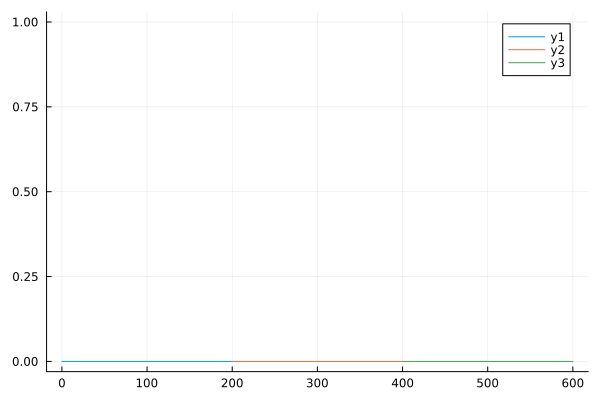

In [ ]:
plot(plotN1)
plot!(plotN2[1].+200, plotN2[2])
plot!(plotN3[1].+400, plotN3[2])

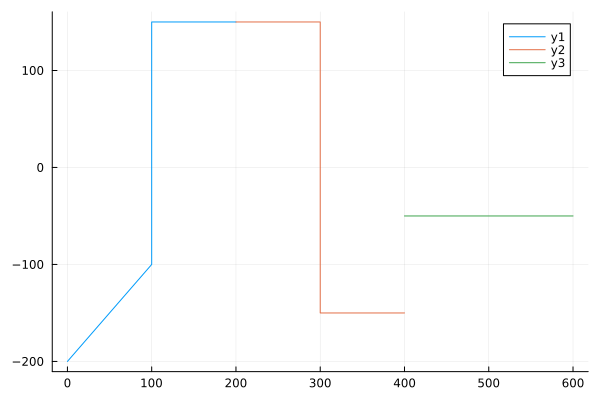

In [65]:
plot(plotT1)
plot!(plotT2[1].+200, plotT2[2])
plot!(plotT3[1].+400, plotT3[2])

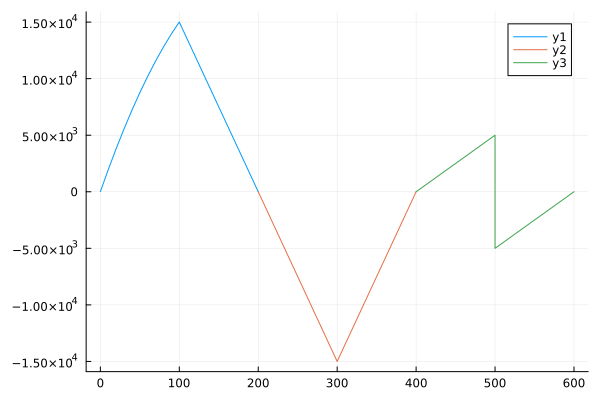

In [66]:
plot(plotMh1)
plot!(plotMh2[1].+200, plotMh2[2])
plot!(plotMh3[1].+400, plotMh3[2])

In [67]:
openPostProcessor()